building the model which can predict the avenger
 * it is like iris data set of avengers .

In [2]:
import numpy as np
import pandas as pd
import requests
import json
import io

In [3]:
link = "https://datasets-server.huggingface.co/rows?dataset=jrtec%2FSuperheroes&config=default&split=train&offset=0&length=100"
s = requests.get(link).content
df = pd.read_csv(io.StringIO(s.decode('utf-8')))

In [4]:
df

,"{""features"":[{""feature_idx"":0","name:""name""","type:{""dtype"":""string""","_type:""Value""}}","{""feature_idx"":1","name:""real_name""","type:{""dtype"":""string"".1","_type:""Value""}}.1","{""feature_idx"":2","name:""full_name""",...,has_durability:1.0.44,has_stamina:1.0.56,has_agility:1.0.56,has_super_strength:1.0.51,id:6665,"prompt:""hero: ""}.99",truncated_cells:[]}],num_rows_total:1158,num_rows_per_page:100,partial:false}


In [5]:
! pip install Faker

In [6]:
import pandas as pd
import numpy as np
from faker import Faker
import random

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)
fake = Faker()
Faker.seed(42)

# Number of rows
n_rows = 1000
classes = ['Spiderman', 'Ironman', 'Hulk', 'Captain America', 'Black Widow']
rows_per_class = n_rows // len(classes)  # 200 each

# Helper: generate a power description based on class
def get_power(avenger):
    powers = {
        'Spiderman': [
            'Web-slinging, wall-crawling, spider-sense',
            'Superhuman agility Lift cars and punch through walls and strength, cling to walls',
            'Genius-level intellect, web shooters, spider-sense',
            'great power comes great responsibility , Leap extreme distances and flip effortlessly.',
            'Wall-Crawling Adhere to any surface via static force.webshooter silk formation.',
            'Regenerative Healing Recover from broken bones and injuries rapidly , with enhance durability.'
        ],
        'Ironman': [
            'Powered armor suit with repulsors and flight',
            'Genius engineer, energy weapons, missile launchers',
            'Nanotechnology suit, super strength, flight',
            'Repulsor Blasts ,Cyberpathic Interface Unibeam: A devastating, concentrated energy blast emitted from the chest reactor.',
            'Advanced Durability: Shell made of gold-titanium alloy resists missiles and energy attacks.',
            'AI Assistance: Real-time tactical analysis and hacking via systems like JARVIS or FRIDAY.'
        ],
        'Hulk': [
            'Superhuman strength ,anger and durability, healing factor',
            'he is very powerful when he is angry'
            'Infinite strength proportional to anger, thunder claps',
            'Gamma radiation empowered, massive leaps and anger',
            'Invulnerability: Skin resists nuclear blasts, artillery shells, and extreme temperatures',
            'Thunderclap: Slamming hands together creates shockwaves that deafen foes and blow away targets.',
            'Environmental Adaptation: Survive indefinitely in the vacuum of space or deep ocean pressures.'
        ],
        'Captain America': [
            'Super-soldier peak human abilities, vibranium shield',
            'Enhanced strength, endurance, martial arts expert',
            'Indomitable will, expert tactician, shield throwing',
            'Bench-press 1,100 pounds and snap steel chains.',
            'Enhanced Reflexes: See fast-moving objects in slow motion to dodge bullets.',
            'Master Tactician: Genius-level combat strategy, battlefield analysis, and leadership.',
            'Vibranium Shield Mastery: Perfect ricochet physics knowledge for offensive and defensive throws.',
            'Immunity to Fatigue: Metabolism prevents lactic acid buildup, allowing endless fighting.',
            'went to past, leader ship quality , worthy among all avengers ,lift thor hammer'
        ],
        'Black Widow': [
            'Master spy, martial artist, expert marksman',
            'Peak human conditioning, espionage, wrist stingers',
            'Acrobatics, hand-to-hand combat, tactical genius',
            'Biochemically Enhanced Longevity: Red Room serum slows her aging and boosts her immune system.',
            'Expert Marksman: Flawless accuracy with firearms, throwing knives, and ranged weapons.',
            'Widow Bite: Wrist gauntlets delivering high-voltage electrical blasts and tear gas.',
            'Multilingualism: Fluent in dozens of languages for global undercover operations.',
            'Healing: Recover from deep wounds, fractures, and trauma much faster than normal humans.',
            'Elite Spy & Tactician: Master of psychological manipulation, interrogation, stealth, and hacking.'
        ]
    }
    return random.choice(powers[avenger])

# Define per‑class distributions for numeric features
# Each tuple = (mean, std_dev) - values clipped to 0-100
stats = {
    'Spiderman': {
        'strength': (60, 8), 'intelligence': (75, 7), 'agility': (95, 4),
        'movies_in': (5, 1.5)
    },
    'Ironman': {
        'strength': (70, 9), 'intelligence': (98, 2), 'agility': (65, 8),
        'movies_in': (9, 1.2)
    },
    'Hulk': {
        'strength': (98, 2), 'intelligence': (40, 10), 'agility': (50, 12),
        'movies_in': (5, 1.5)
    },
    'Captain America': {
        'strength': (85, 5), 'intelligence': (80, 6), 'agility': (80, 6),
        'movies_in': (7, 1.2)
    },
    'Black Widow': {
        'strength': (55, 7), 'intelligence': (85, 5), 'agility': (92, 4),
        'movies_in': (6, 1.3)
    }
}

data = []

for avenger in classes:
    for _ in range(rows_per_class):
        # 1. Name (target)
        name = avenger

        # 2. Power description
        power = get_power(avenger)

        # 3. Gender
        gender = 'Female' if avenger == 'Black Widow' else 'Male'

        # 4. Unique description - combine a random sentence with avenger specific info
        description = fake.sentence(nb_words=12) + f" {avenger} once saved the day."

        # 5. In Endgame? 95% True for all (most heroes appeared)
        in_endgame = random.random() < 0.95

        # 6. Movies_in (integer, clipped to 1-10)
        mu_movies, sigma_movies = stats[avenger]['movies_in']
        movies_in = int(np.clip(np.random.normal(mu_movies, sigma_movies), 1, 10))

        # 7-9. Numeric features (strength, intelligence, agility)
        mu_s, sigma_s = stats[avenger]['strength']
        strength = int(np.clip(np.random.normal(mu_s, sigma_s), 0, 100))

        mu_i, sigma_i = stats[avenger]['intelligence']
        intelligence = int(np.clip(np.random.normal(mu_i, sigma_i), 0, 100))

        mu_a, sigma_a = stats[avenger]['agility']
        agility = int(np.clip(np.random.normal(mu_a, sigma_a), 0, 100))

        data.append([name, power, gender, description, in_endgame, movies_in,
                     strength, intelligence, agility])

# Create DataFrame
columns = ['name', 'power', 'gender', 'description', 'in_endgame',
           'movies_in', 'strength', 'intelligence', 'agility']
df = pd.DataFrame(data, columns=columns)

# Shuffle the rows
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV
df.to_csv('avengers_dataset.csv', index=False)

# Show first 10 rows and dataset info
print("First 10 rows of the generated dataset:")
print(df.head(10))
print("\nDataset shape:", df.shape)
print("\nClass distribution:\n", df['name'].value_counts())
print("\nColumn data types:\n", df.dtypes)

First 10 rows of the generated dataset:
              name                                              power  gender  \
0             Hulk  Superhuman strength ,anger and durability, hea...    Male   
1  Captain America  Super-soldier peak human abilities, vibranium ...    Male   
2  Captain America  Indomitable will, expert tactician, shield thr...    Male   
3  Captain America  went to past, leader ship quality , worthy amo...    Male   
4             Hulk  Superhuman strength ,anger and durability, hea...    Male   
5  Captain America  Enhanced strength, endurance, martial arts expert    Male   
6  Captain America    Bench-press 1,100 pounds and snap steel chains.    Male   
7             Hulk  Invulnerability: Skin resists nuclear blasts, ...    Male   
8      Black Widow  Widow Bite: Wrist gauntlets delivering high-vo...  Female   
9        Spiderman  Wall-Crawling Adhere to any surface via static...    Male   

                                         description  in_endgame  mo

In [7]:
df

,name,power,gender,description,in_endgame,movies_in,strength,intelligence,agility
0,Hulk,"Superhuman strength ,anger and durability, hea...",Male,White magazine after teacher base own test. Hu...,True,4,95,34,48
1,Captain America,"Super-soldier peak human abilities, vibranium ...",Male,Face charge leg those behavior responsibility ...,True,6,76,87,84
2,Captain America,"Indomitable will, expert tactician, shield thr...",Male,Source central that natural why sit beautiful ...,True,6,81,76,73
3,Captain America,"went to past, leader ship quality , worthy amo...",Male,Method produce about point walk focus plant th...,True,9,83,74,76
4,Hulk,"Superhuman strength ,anger and durability, hea...",Male,So film media food accept rate game right patt...,True,3,98,38,61
...,...,...,...,...,...,...,...,...,...
995,Spiderman,"great power comes great responsibility , Leap ...",Male,Their four old center glass whose recognize ho...,True,5,70,68,97
996,Ironman,Powered armor suit with repulsors and flight,Male,Room wear throughout series most adult above s...,True,8,66,97,81
997,Black Widow,Multilingualism: Fluent in dozens of languages...,Female,Most west there subject themselves property ma...,True,6,50,85,98
998,Hulk,Environmental Adaptation: Survive indefinitely...,Male,Range much often party tough movement action l...,True,4,97,40,63


understanding the data

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df.info()
# since generated with faker thats why it is consistent and easy to use
# no missing values no dublicates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          1000 non-null   object
 1   power         1000 non-null   object
 2   gender        1000 non-null   object
 3   description   1000 non-null   object
 4   in_endgame    1000 non-null   bool  
 5   movies_in     1000 non-null   int64 
 6   strength      1000 non-null   int64 
 7   intelligence  1000 non-null   int64 
 8   agility       1000 non-null   int64 
dtypes: bool(1), int64(4), object(4)
memory usage: 63.6+ KB


In [10]:
df.describe()

,movies_in,strength,intelligence,agility
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.933000,73.164000,74.948000,76.074000
std,2.023018,17.498094,20.682579,18.342327
min,1.000000,36.000000,12.000000,14.000000
25%,4.000000,58.000000,69.000000,63.000000
50%,6.000000,72.000000,80.000000,81.000000
75%,7.000000,89.000000,89.000000,92.000000
max,10.000000,100.000000,100.000000,100.000000


<Axes: xlabel='count', ylabel='name'>

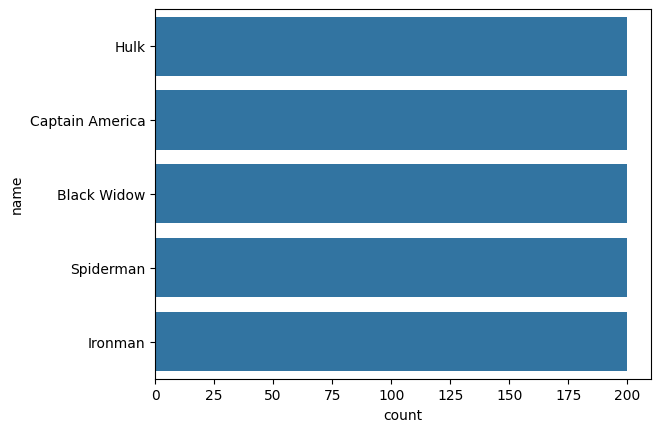

In [11]:
sns.countplot(df['name'])

# the obivous one as generated not real world but that is ok as we are dealing with the data which is fixed will not change

<Axes: xlabel='count', ylabel='gender'>

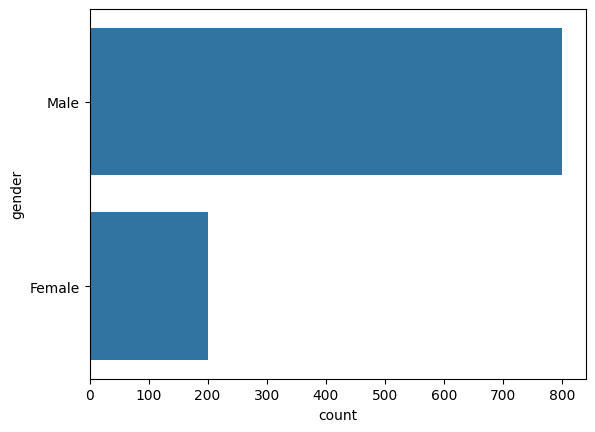

In [12]:
sns.countplot(df['gender'])
# obivous as we have black widow as the only women now can taken in mind to give more weight to the black widow

In [13]:
!pip install nltk

In [14]:
import nltk

In [15]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [16]:
from nltk.corpus import stopwords
import string

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [17]:
# text Transforming
def transform(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []

  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [18]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
df['power'] = df['power'].apply(transform)

In [20]:
df['description'] = df['description'].apply(transform)

Most common words for Black Widow's powers:
[('wrist', 52), ('spi', 49), ('master', 49), ('human', 44), ('expert', 39), ('marksman', 39), ('widow', 32), ('bite', 32), ('gauntlet', 32), ('deliv', 32)]


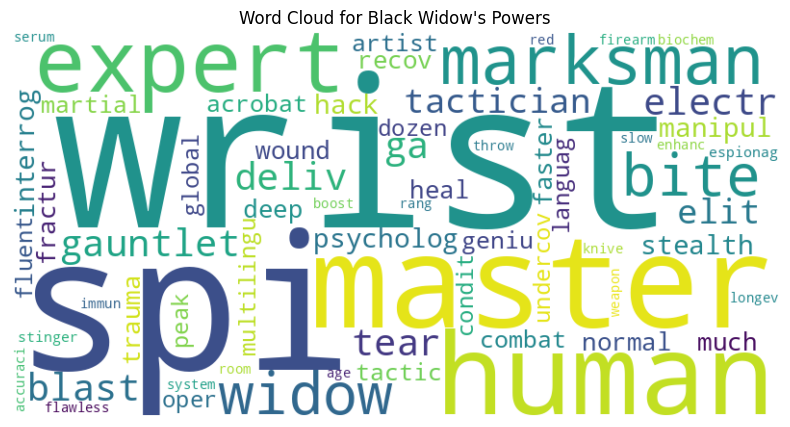

In [21]:
from collections import Counter
from wordcloud import WordCloud

black_widow_powers = df[df['name'] == 'Black Widow']['power']

text = " ".join(black_widow_powers.astype(str))

# Tokenize and count words
words = text.split()
word_counts = Counter(words)

print("Most common words for Black Widow's powers:")
print(word_counts.most_common(10)) # Print top 10 most common words

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Black Widow\'s Powers')
plt.show()

Most common words for iron man's powers:
[('energi', 95), ('suit', 68), ('repulsor', 68), ('flight', 68), ('blast', 68), ('missil', 61), ('ai', 37), ('assist', 37), ('tactic', 37), ('analysi', 37)]


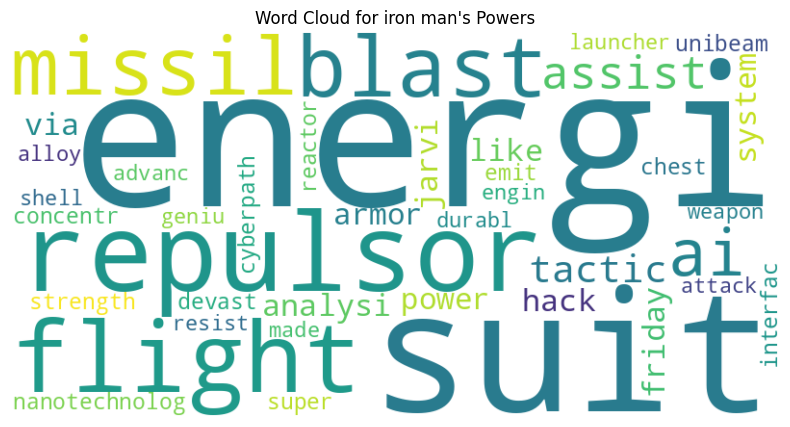

In [22]:
ironman_powers = df[df['name'] == 'Ironman']['power']

text = " ".join(ironman_powers.astype(str))

# Tokenize and count words
words = text.split()
word_counts = Counter(words)

print("Most common words for iron man's powers:")
print(word_counts.most_common(10)) # Print top 10 most common words

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for iron man\'s Powers')
plt.show()

Most common words for captian powers:
[('shield', 68), ('tactician', 54), ('expert', 51), ('throw', 48), ('enhanc', 44), ('vibranium', 43), ('master', 29), ('combat', 29), ('strategi', 29), ('battlefield', 29)]


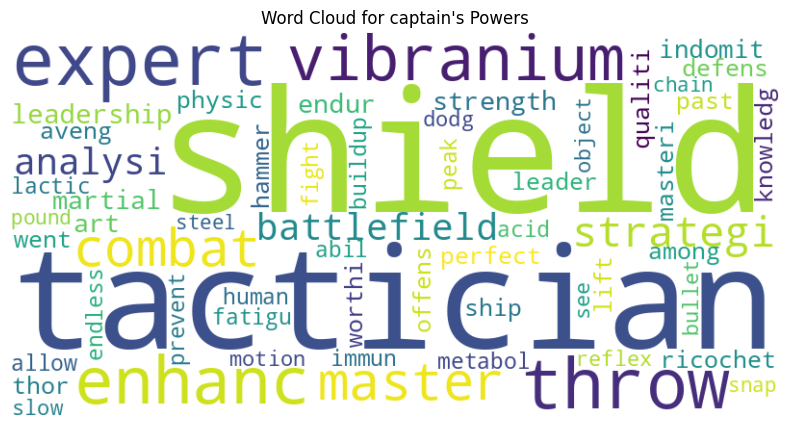

In [23]:
captian = df[df['name']=='Captain America']['power']

text = ' '.join(captian.astype(str))

words = text.split()
word_counts = Counter(words)

print("Most common words for captian powers:")
print(word_counts.most_common(10)) # Print top 10 most common words

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for captain\'s Powers')
plt.show()

Most common words for Spiderman's powers:
[('wall', 74), ('great', 70), ('superhuman', 37), ('agil', 37), ('lift', 37), ('car', 37), ('punch', 37), ('strength', 37), ('cling', 37), ('power', 35)]


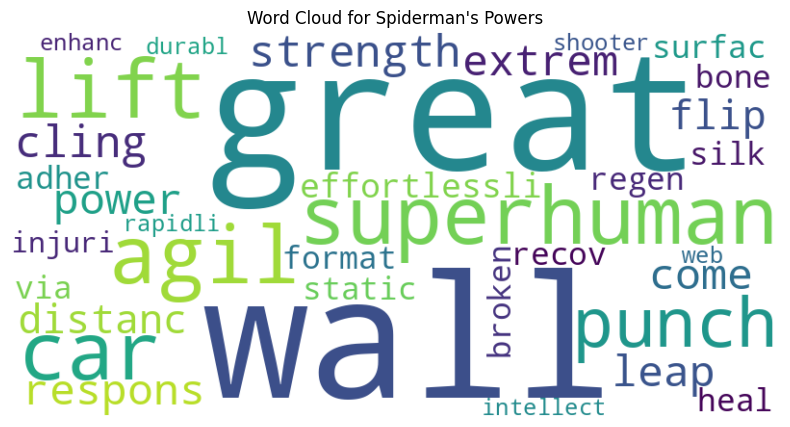

In [24]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Spiderman Word Cloud
spiderman_powers = df[df['name'] == 'Spiderman']['power']
text_spiderman = " ".join(spiderman_powers.astype(str))
words_spiderman = text_spiderman.split()
word_counts_spiderman = Counter(words_spiderman)

print("Most common words for Spiderman's powers:")
print(word_counts_spiderman.most_common(10))

wordcloud_spiderman = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts_spiderman)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_spiderman, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Spiderman\'s Powers')
plt.show()




Most common words for Hulk's powers:
[('anger', 95), ('strength', 58), ('invulner', 42), ('skin', 42), ('resist', 42), ('nuclear', 42), ('blast', 42), ('artilleri', 42), ('shell', 42), ('extrem', 42)]


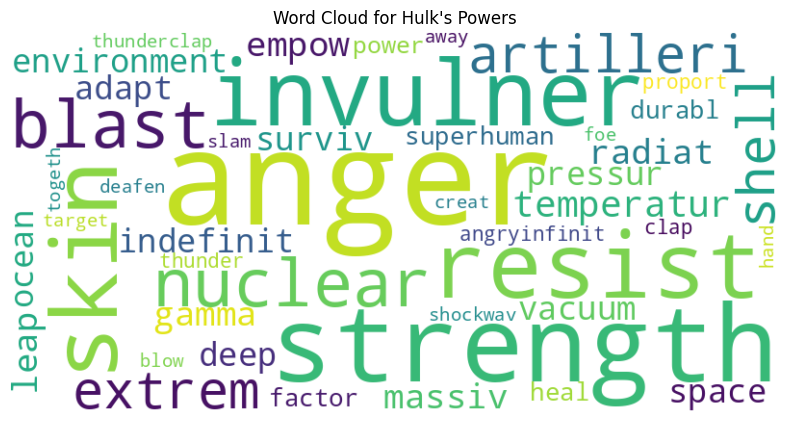

In [25]:
# Hulk Word Cloud
hulk_powers = df[df['name'] == 'Hulk']['power']
text_hulk = " ".join(hulk_powers.astype(str))
words_hulk = text_hulk.split()
word_counts_hulk = Counter(words_hulk)

print("\nMost common words for Hulk's powers:")
print(word_counts_hulk.most_common(10))

wordcloud_hulk = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts_hulk)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_hulk, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Hulk\'s Powers')
plt.show()

In [26]:
df[df['in_endgame'] == False]

# this here represent the bias
# all 5 were in the endgame
# thus we cannot drop this column

,name,power,gender,description,in_endgame,movies_in,strength,intelligence,agility
51,Black Widow,biochem enhanc longev red room serum slow age ...,Female,find could realli mr former articl light black...,False,4,57,91,83
73,Captain America,immun fatigu metabol prevent lactic acid build...,Male,colleg fast attent offic govern author repres ...,False,8,83,82,76
84,Ironman,geniu engin energi weapon missil launcher,Male,region miss stop strong enjoy name commun pres...,False,7,67,100,66
117,Black Widow,peak human condit espionag wrist stinger,Female,wide husband hope miss instead live focu retur...,False,7,49,77,91
133,Black Widow,widow bite wrist gauntlet deliv electr blast t...,Female,tax low keep news court control black widow sa...,False,7,66,100,87
136,Spiderman,,Male,mind song risk bad state nation fli bag produc...,False,4,52,63,95
153,Hulk,power angryinfinit strength proport anger thun...,Male,feel quickli truth view respons trip wrong old...,False,5,98,47,44
159,Black Widow,heal recov deep wound fractur trauma much fast...,Female,forc matter bring nice help histori listen fin...,False,6,49,84,91
162,Captain America,master tactician combat strategi battlefield a...,Male,piec put recent popul end lay race effect weig...,False,6,86,87,77
167,Captain America,vibranium shield masteri perfect ricochet phys...,Male,babi drive behavior offer experi upon space ca...,False,7,81,73,83


<Axes: xlabel='strength', ylabel='Count'>

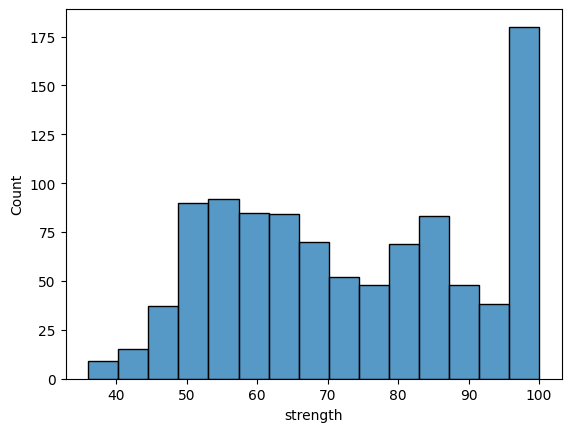

In [27]:
sns.histplot(df['strength'],bins=15)

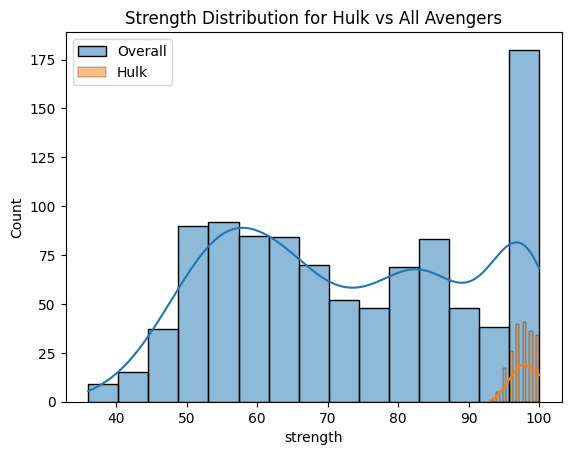

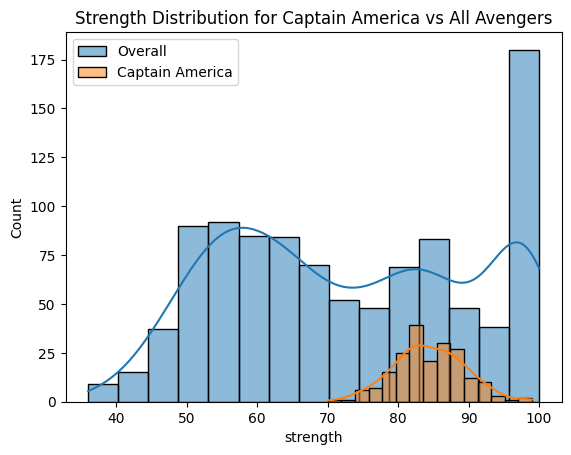

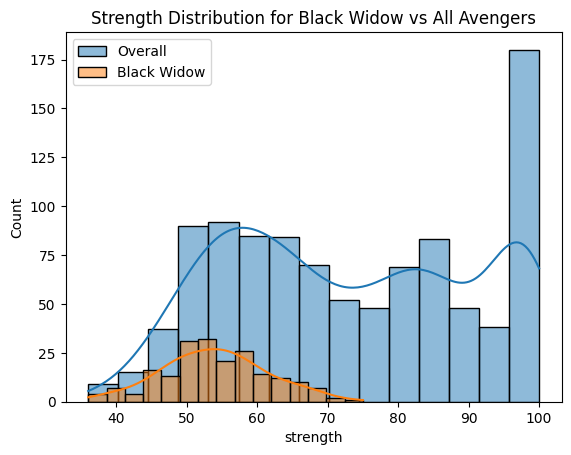

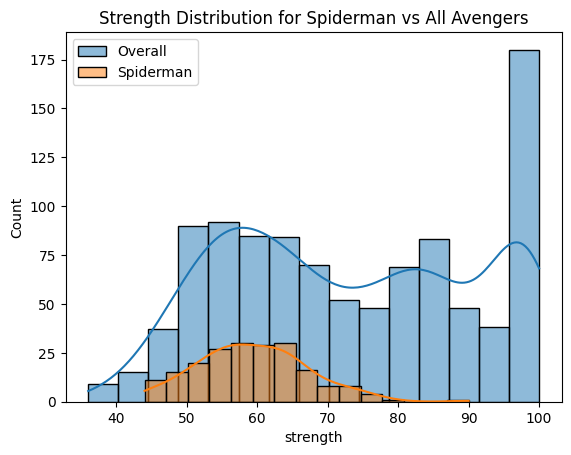

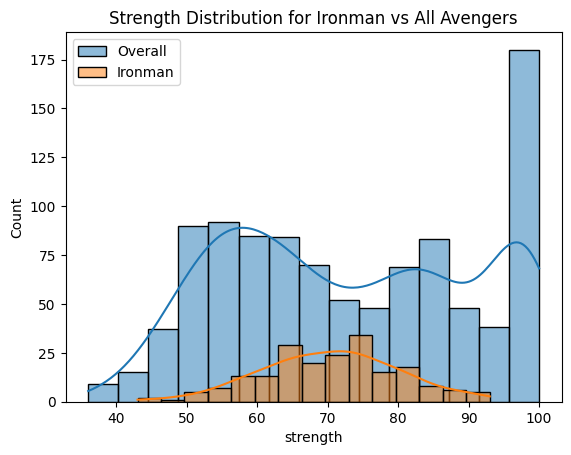

In [28]:
# creating the distribution plot with respect to each avenger

avengers = ['Hulk','Captain America','Black Widow','Spiderman','Ironman']

for i in avengers:
  sns.histplot(df['strength'], bins=15, kde=True, label='Overall')
  sns.histplot(df[df['name'] == i ]['strength'], bins=15, kde=True, label=i)
  plt.title(f'Strength Distribution for {i} vs All Avengers')
  plt.legend()
  plt.show()

In [29]:
df.to_csv('avengers_dataset.csv', index=False)

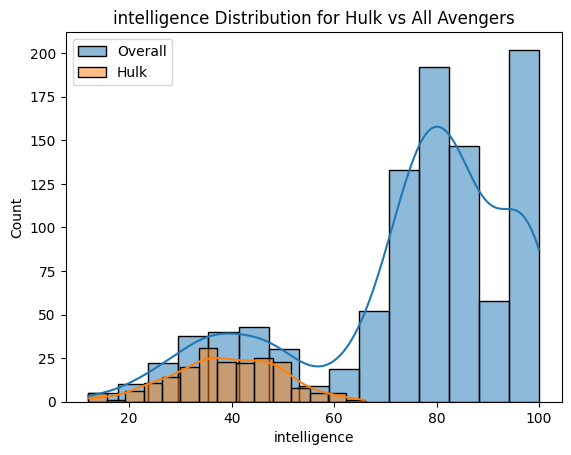

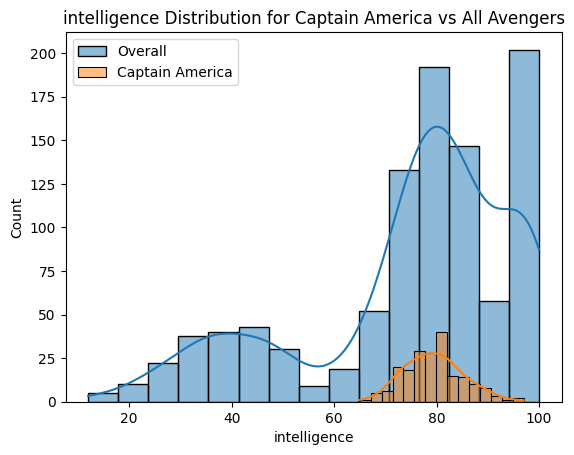

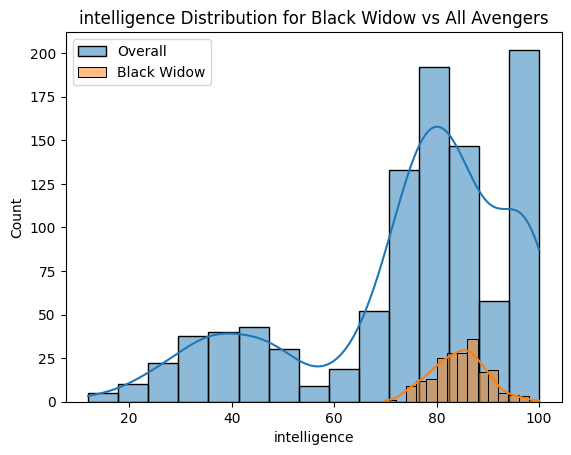

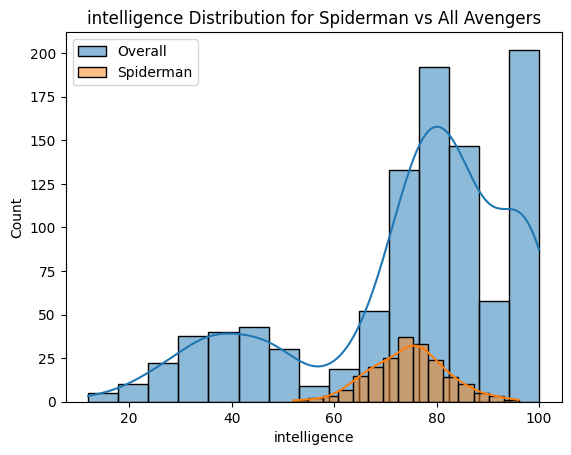

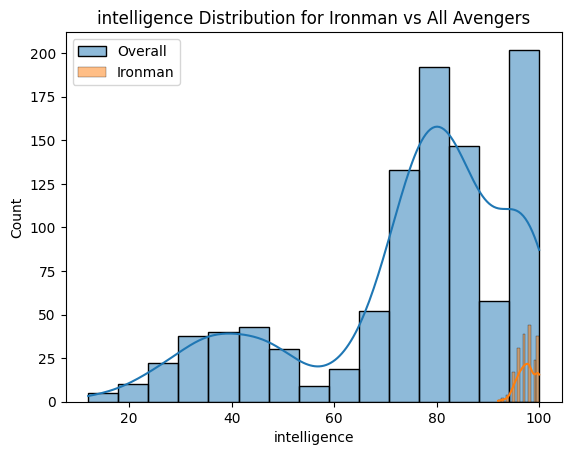

In [30]:
# creating the distribution plot with respect to each avenger

avengers = ['Hulk','Captain America','Black Widow','Spiderman','Ironman']

for i in avengers:
  sns.histplot(df['intelligence'], bins=15, kde=True, label='Overall')
  sns.histplot(df[df['name'] == i ]['intelligence'], bins=15, kde=True, label=i)
  plt.title(f'intelligence Distribution for {i} vs All Avengers')
  plt.legend()
  plt.show()

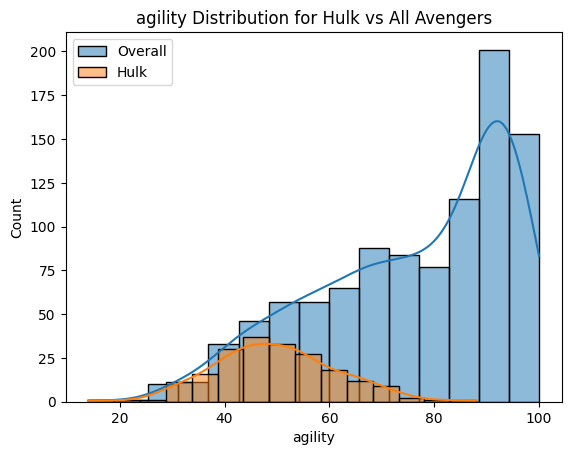

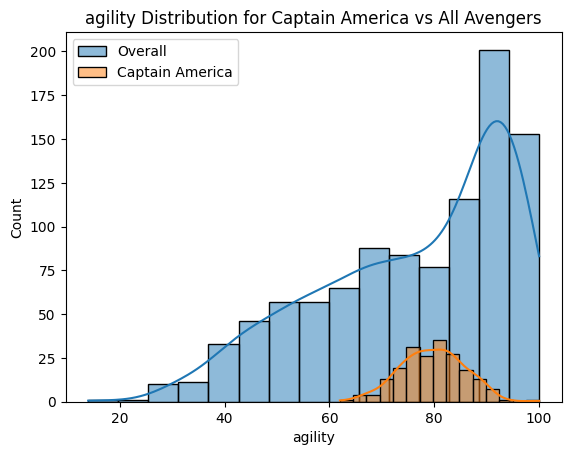

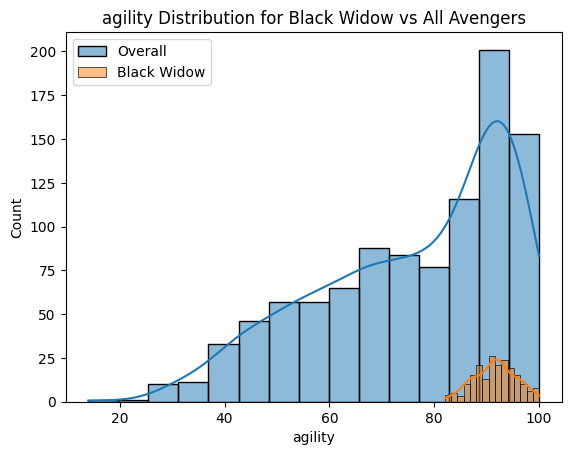

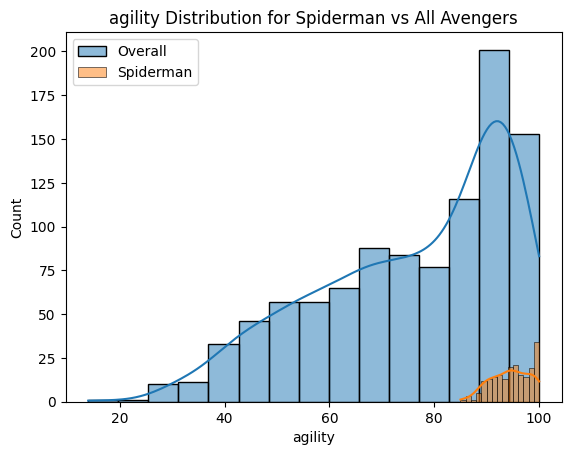

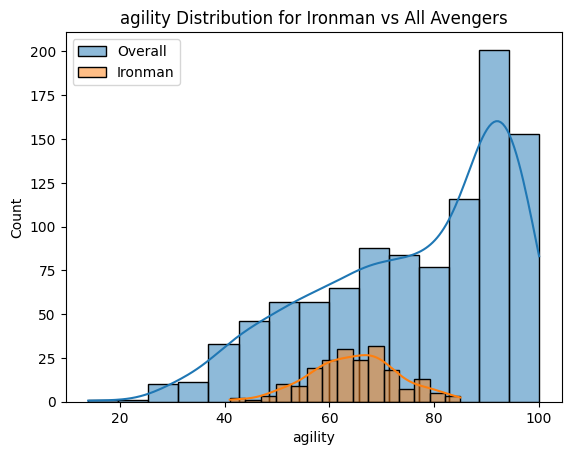

In [31]:
# creating the distribution plot with respect to each avenger

avengers = ['Hulk','Captain America','Black Widow','Spiderman','Ironman']

for i in avengers:
  sns.histplot(df['agility'], bins=15, kde=True, label='Overall')
  sns.histplot(df[df['name'] == i ]['agility'], bins=15, kde=True, label=i)
  plt.title(f'agility Distribution for {i} vs All Avengers')
  plt.legend()
  plt.show()

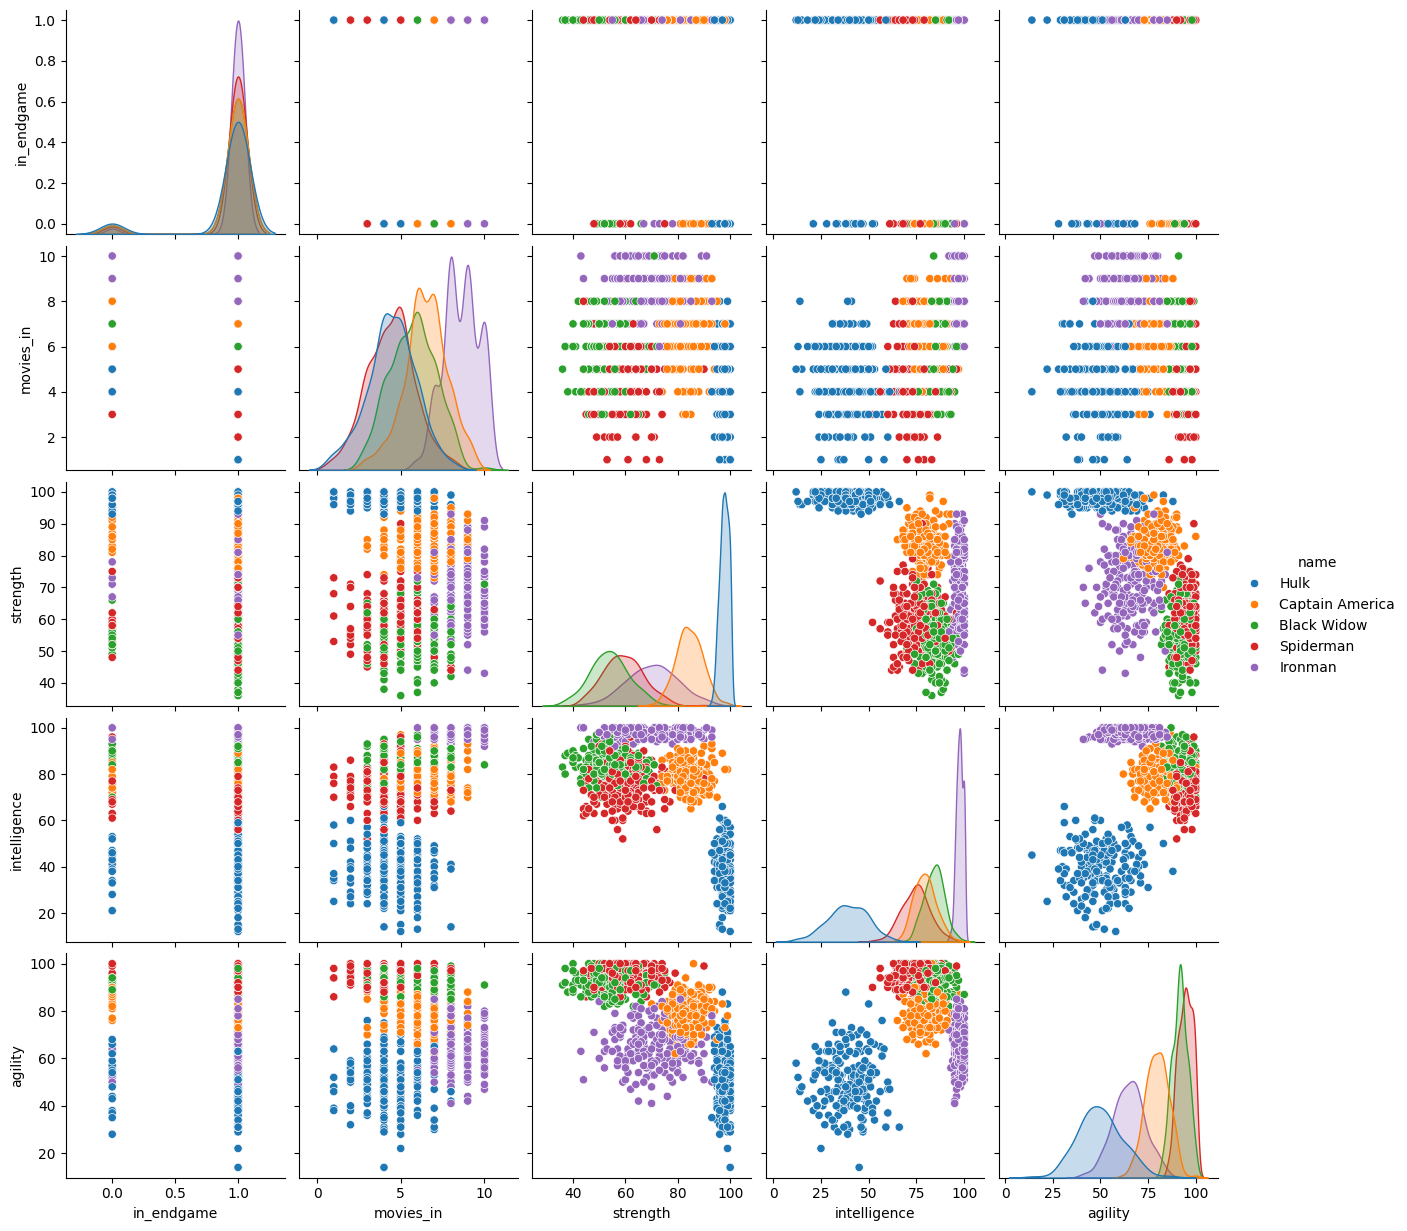

In [32]:
sns.pairplot(df, hue='name')

In [33]:
avengers = ['Hulk', 'Captain America', 'Black Widow', 'Spiderman', 'Ironman']

for avenger in avengers:
    print(f"\nCorrelation matrix for {avenger}:")
    # Filter for the current avenger and select numerical columns
    correlation_matrix = df[df['name'] == avenger][['intelligence', 'movies_in', 'agility', 'strength']].corr()
    print(correlation_matrix)


Correlation matrix for Hulk:
              intelligence  movies_in   agility  strength
intelligence      1.000000  -0.105583  0.020153 -0.099300
movies_in        -0.105583   1.000000 -0.038982 -0.007513
agility           0.020153  -0.038982  1.000000 -0.062701
strength         -0.099300  -0.007513 -0.062701  1.000000

Correlation matrix for Captain America:
              intelligence  movies_in   agility  strength
intelligence      1.000000  -0.055270  0.081064 -0.082150
movies_in        -0.055270   1.000000 -0.055293  0.051001
agility           0.081064  -0.055293  1.000000  0.132342
strength         -0.082150   0.051001  0.132342  1.000000

Correlation matrix for Black Widow:
              intelligence  movies_in   agility  strength
intelligence      1.000000  -0.002135  0.017865 -0.033762
movies_in        -0.002135   1.000000 -0.076461  0.092741
agility           0.017865  -0.076461  1.000000 -0.120329
strength         -0.033762   0.092741 -0.120329  1.000000

Correlation matrix fo

model building

In [34]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , OrdinalEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix

In [35]:
from sklearn.preprocessing import OrdinalEncoder

tranformed_col = ColumnTransformer([
    ('gender', OrdinalEncoder(), ['gender']),
    ('in_endgame', OrdinalEncoder(), ['in_endgame']),
    ('power', CountVectorizer(max_features=5000), 'power'),
    ('description', CountVectorizer(max_features=5000), 'description')
], remainder='passthrough')

In [36]:
tranformed_col

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('gender', ...), ('in_endgame', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [37]:
X_train , X_test , y_train , y_test = train_test_split(df.drop(columns=['name']),df['name'],test_size=0.2,random_state=42)

# Encode target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [38]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB , MultinomialNB , BernoulliNB
from sklearn.svm import SVC

In [39]:
pipe = make_pipeline(
    tranformed_col,
    LogisticRegressionCV(max_iter=100)
)

pipe.fit(X_train, y_train_encoded)
y_pred_encoded = pipe.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred_encoded)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_encoded))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/

Accuracy: 0.995
Confusion Matrix:
[[39  0  0  0  0]
 [ 0 37  0  0  0]
 [ 0  0 41  0  0]
 [ 0  1  0 35  0]
 [ 0  0  0  0 47]]


In [40]:
pipe2 = make_pipeline(
    tranformed_col,
    KNeighborsClassifier(n_neighbors=5)
)

pipe2.fit(X_train, y_train_encoded)
y_pred = pipe2.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))

Accuracy: 0.95
Confusion Matrix:
[[35  0  0  0  4]
 [ 0 37  0  0  0]
 [ 0  0 41  0  0]
 [ 0  1  0 35  0]
 [ 5  0  0  0 42]]


In [41]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.naive_bayes import GaussianNB

pipe3 = make_pipeline(
    tranformed_col,
    FunctionTransformer(lambda x: x.toarray(), accept_sparse=True), # Convert sparse to dense
    GaussianNB()
)

pipe3.fit(X_train, y_train_encoded)
y_pred = pipe3.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))

Accuracy: 0.985
Confusion Matrix:
[[39  0  0  0  0]
 [ 0 37  0  0  0]
 [ 0  0 41  0  0]
 [ 0  0  0 36  0]
 [ 1  0  1  1 44]]


In [42]:
pipe4 = make_pipeline(
    tranformed_col,
    MultinomialNB()
)

pipe4.fit(X_train, y_train_encoded)
y_pred = pipe4.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))

Accuracy: 1.0
Confusion Matrix:
[[39  0  0  0  0]
 [ 0 37  0  0  0]
 [ 0  0 41  0  0]
 [ 0  0  0 36  0]
 [ 0  0  0  0 47]]


In [43]:
pipe5 = make_pipeline(
    tranformed_col,
    SVC()
)

pipe5.fit(X_train, y_train_encoded)
y_pred = pipe5.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))

Accuracy: 0.915
Confusion Matrix:
[[33  0  0  0  6]
 [ 0 37  0  0  0]
 [ 0  0 41  0  0]
 [ 0  1  0 35  0]
 [10  0  0  0 37]]


### Exporting the Multinomial Naive Bayes Model

To use the trained model for future predictions without retraining, we can save it to a file. We'll also save the `LabelEncoder` used for the target variable, as it's needed to transform numerical predictions back into Avenger names.

In [44]:
import joblib

# Save the Multinomial Naive Bayes pipeline
joblib.dump(pipe4, 'multinomial_nb_model.pkl')

# Save the LabelEncoder
joblib.dump(le, 'label_encoder.pkl')

print("Model and LabelEncoder saved successfully!")

Model and LabelEncoder saved successfully!


### Loading the Model and Making Predictions

Now, let's load the saved model and `LabelEncoder` and use them to predict the Avenger for a hypothetical new entry.

In [45]:
import joblib
import pandas as pd

# Load the saved model and label encoder
loaded_pipe = joblib.load('multinomial_nb_model.pkl')
loaded_le = joblib.load('label_encoder.pkl')

print("Model and LabelEncoder loaded successfully!")

Model and LabelEncoder loaded successfully!


In [46]:

sample_data = pd.DataFrame([
    {
        'power': 'Superhuman strength, invulnerability, healing factor, anger-powered',
        'gender': 'Male',
        'description': 'A very strong, green giant who gets stronger with anger. He smashes everything.',
        'in_endgame': True,
        'movies_in': 5,
        'strength': 99,
        'intelligence': 30,
        'agility': 40
    }
])

# Apply the same text transformation to the sample data
# Make sure the 'transform' function from earlier is defined in the environment
sample_data['power'] = sample_data['power'].apply(transform)
sample_data['description'] = sample_data['description'].apply(transform)

display(sample_data)

,power,gender,description,in_endgame,movies_in,strength,intelligence,agility
0,superhuman strength invulner heal factor,Male,strong green giant get stronger anger smash ev...,True,5,99,30,40


In [47]:
# Make a prediction using the loaded pipeline
predicted_label_encoded = loaded_pipe.predict(sample_data)

# Inverse transform the predicted label to get the Avenger's name
predicted_avenger = loaded_le.inverse_transform(predicted_label_encoded)

print(f"The predicted Avenger for the given attributes is: {predicted_avenger[0]}")

The predicted Avenger for the given attributes is: Hulk
